# Diffusion Processes

A **diffusion process** is a quantity that changes over time, where every moment adds a small push in some direction plus a small random jolt. A stock price, an interest rate, the position of a speck of dust in water -- each one drifts somewhere while being knocked around randomly.

You describe one with **two functions**:

- **`drift(x, t)`** -- which way it gets pushed, and how hard. This is the predictable part.
- **`diffusion(x, t)`** -- how big the random jolts are.

Both can depend on the current value `x` and on the time `t`. Written as an equation:

$$dX = \text{drift}(X, t)\,dt + \text{diffusion}(X, t)\,dW$$

where $dW$ is the random jolt. Being able to write those two functions yourself is what makes this general -- a great many named models are nothing more than a particular choice of the two, and there is a table of four standard ones below.

One thing to know up front: the path is built from many small steps, so it is an **approximation**. The `tol` setting controls how small those steps are. The last section says more.

In [1]:
from symbulate import *
import numpy as np
import matplotlib.pyplot as plt

## Build one and draw a path

The example below is *geometric Brownian motion*, the textbook stock price model. Both functions are proportional to `x`, which does two things: a price near 100 moves in bigger jumps than a price near 1, and since both shrink to nothing as `x` approaches 0, the price can never go negative.

`x0` is where every path starts.

In [2]:
stock_price = DiffusionProcess(
    drift=lambda x, t: 0.05 * x,
    diffusion=lambda x, t: 0.4 * x,
    x0=100,
)

One draw is **not a number** -- it is a whole path, a function of time. Ask it about any time `t >= 0`.

In [3]:
path = stock_price.draw()
[round(float(path(t)), 2) for t in [0, 1, 2, 5, 10]]

[100.0, 127.7, 131.97, 81.67, 86.82]

Every path starts at `x0 = 100` exactly. After that it is random, so a second draw is a completely different path.

In [4]:
second = stock_price.draw()
round(float(path(10)), 2), round(float(second(10)), 2)

(86.82, 128.82)

## Simulate and plot sample paths

Drawing several at once shows the range of things that can happen.

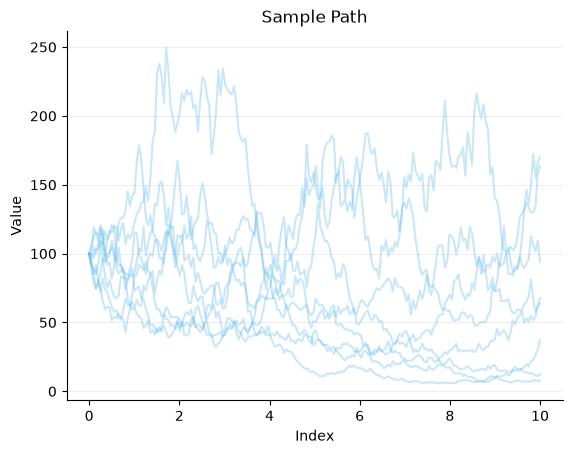

In [5]:
stock_price.sim(8).plot(tmin=0, tmax=10)

## Four standard models

These are the recipes. Every one is the same `DiffusionProcess` call with different functions:

| Model | `drift(x, t)` | `diffusion(x, t)` |
|---|---|---|
| Brownian motion | `0` | `sigma` |
| Ornstein-Uhlenbeck | `rate * (mean - x)` | `sigma` |
| Geometric Brownian motion | `mu * x` | `sigma * x` |
| Cox-Ingersoll-Ross | `rate * (mean - x)` | `sigma * sqrt(max(x, 0))` |

**Brownian motion.** A drift of 0 and a constant jolt size. Nothing pulls it anywhere, so it wanders off and never comes back.

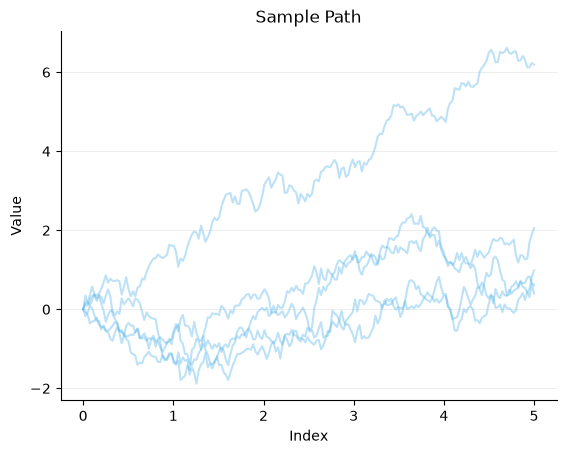

In [6]:
DiffusionProcess(
    drift=lambda x, t: 0,
    diffusion=lambda x, t: 1,
    x0=0,
).sim(5).plot(tmin=0, tmax=5)

**Ornstein-Uhlenbeck.** The drift points back toward `mean`, and gets stronger the further away the value is -- like a spring. Started at 10 with a mean of 0, the paths get dragged down and then wander around 0 instead of running off. Used for interest rates and anything else that moves but stays put on average.

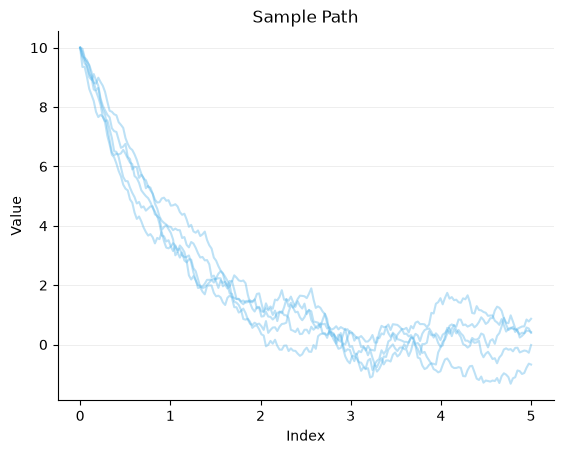

In [7]:
DiffusionProcess(
    drift=lambda x, t: 1.0 * (0 - x),
    diffusion=lambda x, t: 1,
    x0=10,
).sim(5).plot(tmin=0, tmax=5)

**Cox-Ingersoll-Ross.** Same spring-like drift, but the jolt size shrinks as the value approaches 0, so the path can never cross it. That is why it is used for interest rates, which should not go negative. Note the `max(x, 0)` inside the square root -- the last section explains why it is needed.

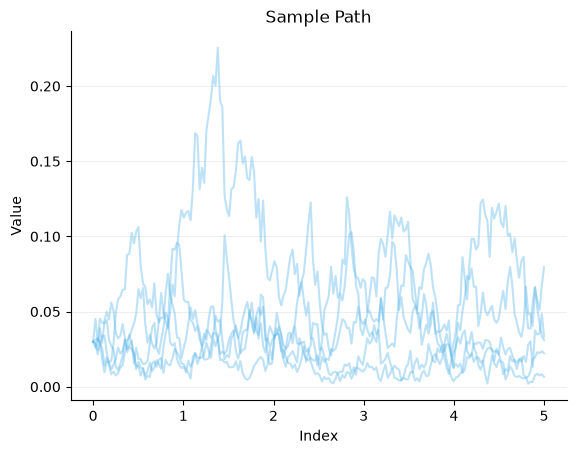

In [8]:
DiffusionProcess(
    drift=lambda x, t: 2.0 * (0.05 - x),
    diffusion=lambda x, t: 0.3 * np.sqrt(max(x, 0)),
    x0=0.03,
).sim(5).plot(tmin=0, tmax=5)

## Checking it against a known answer

Since the simulation is approximate, it is worth seeing that it lands where it should. Geometric Brownian motion is one of the few models with a simple formula for its average: starting at `x0` and growing at rate `mu`, the average value at time `t` is

$$x_0 \, e^{\mu t}$$

For our stock price that is `100 * exp(0.05 * 2)` after 2 years.

In [9]:
simulated = stock_price[2.0].sim(2000).mean()
formula = 100 * np.exp(0.05 * 2)
round(float(simulated), 2), round(float(formula), 2)

(108.18, 110.52)

## The value at a fixed time

The value at one particular time is itself a random variable. Write `X[t]` to get it, then treat it like any other -- simulate it, plot it, take its mean.

Currently Showing: Histogram (Default)
Alternative Plots: Rug Plot (type = "rug"), Density Plot (type = "density"), Box Plot (type = "box"), Violin Plot (type = "violin"), ECDF Plot (type = "ecdf")


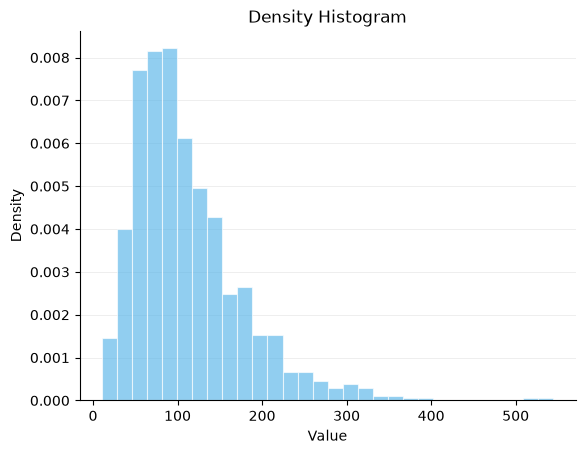

In [10]:
stock_price[2.0].sim(1000).plot()

## Zooming in shows more of the *same* path

This is the part worth understanding, because it is not how you might expect a simulation to work.

The obvious way to simulate a path is to pick a step size, take a few thousand steps, and keep the list of values. But then there is nothing *between* the steps. If you wanted a closer look at the first tiny stretch of time, you would have to simulate a brand new path -- with no relationship to the one you were already looking at.

Symbulate fills a path in **lazily** instead. When you ask about a time it has not seen, and that time falls between two it already knows, it draws a value that fits *both* neighbours. So you can keep zooming in forever and always be looking at the same path, in more and more detail.

The two pictures below are one single draw. The right-hand one is what lives inside the shaded sliver on the left.

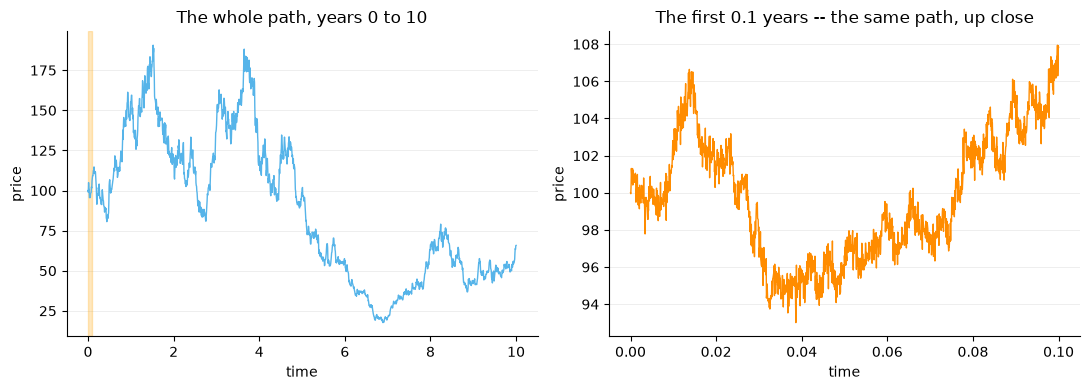

In [11]:
zoom_path = stock_price.draw()

whole = np.linspace(0, 10, 1500)
sliver = np.linspace(0, 0.1, 1500)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(whole, [zoom_path(t) for t in whole], lw=1)
axes[0].axvspan(0, 0.1, color="orange", alpha=0.25)
axes[0].set_title("The whole path, years 0 to 10")
axes[0].set_xlabel("time")
axes[0].set_ylabel("price")

axes[1].plot(sliver, [zoom_path(t) for t in sliver], lw=1, color="darkorange")
axes[1].set_title("The first 0.1 years -- the same path, up close")
axes[1].set_xlabel("time")
axes[1].set_ylabel("price")

plt.tight_layout()

And here is the proof that zooming does not quietly rewrite anything: read two times, ask about a pile of times in between, then read the original two again.

In [12]:
check = stock_price.draw()
before = float(check(1.0)), float(check(2.0))

for t in [1.1, 1.25, 1.5, 1.75, 1.9]:
    check(t)

after = float(check(1.0)), float(check(2.0))
before == after

True

## Three things to watch out for

**1. It is approximate, and `tol` is the dial.** The path is built from small steps, and `tol` is the largest step allowed. The default `1e-3` is fine for plotting; a smaller value is more accurate but slower. (If `drift` and `diffusion` are both constants, the simulation happens to be exact whatever you choose.)

**2. A square root in `diffusion` needs a floor.** Write `sigma * np.sqrt(max(x, 0))`, not `sigma * np.sqrt(x)`. A step can land a hair below 0 even in a model that should stay positive, and the square root of a negative number is `nan` -- which then poisons the whole rest of the path. The cell below makes the problem easy to see by using a large `sigma`.

**3. To repeat a run, seed the module's own generator.** `np.random.seed()` will *not* work: it seeds an older NumPy generator that this module never reads.

```python
from symbulate import diffusion_process
diffusion_process.rng = np.random.default_rng(42)
```

In [13]:
def count_ruined(diffusion_func):
    """Out of 20 paths, how many come out as nan."""
    process = DiffusionProcess(
        drift=lambda x, t: 1.0 * (0.05 - x),
        diffusion=diffusion_func,
        x0=0.05,
    )
    with np.errstate(invalid="ignore"):
        values = [float(process.draw()(3.0)) for _ in range(20)]
    return sum(np.isnan(value) for value in values)


print("sqrt(x)          ->", count_ruined(lambda x, t: 0.9 * np.sqrt(x)), "of 20 ruined")
print("sqrt(max(x, 0))  ->", count_ruined(lambda x, t: 0.9 * np.sqrt(max(x, 0))), "of 20 ruined")

sqrt(x)          -> 19 of 20 ruined


sqrt(max(x, 0))  -> 0 of 20 ruined
